In [1]:
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1.Upload dataset(only 2022 for now)

In [2]:
overall_df = pd.read_csv("data/02-processed/final_data.csv")

In [3]:
# overall_df.dtypes

In [4]:
#df2018 = overall_df[overall_df['Season']==2018]
#df2019 = overall_df[overall_df['Season']==2019]
#df2020 = overall_df[overall_df['Season']==2020]
#df2021 = overall_df[overall_df['Season']==2021]
df2022 = overall_df[overall_df['Season']==2022]

In [5]:
df2022.head()

,Player,G,MP,On-Off,TS%,LEBRON,D-LEBRON,O-LEBRON,dpm,d_dpm,o_dpm,raptor_total,raptor_defense,raptor_offense,Season,height_inches,wingspan_inches,relative
0,mikal bridges,82,2854,9.5,0.627,1.376,1.181,0.195,1.21,0.22,0.99,2.7,0.9,1.8,2022,77.75,85.0,7.25
1,miles bridges,80,2837,5.8,0.593,0.797,-0.597,1.393,1.13,-0.28,1.40,1.7,-0.0,1.7,2022,77.25,81.5,4.25
2,demar derozan,76,2743,5.1,0.590,1.265,-1.530,2.794,0.40,-1.23,1.63,1.4,-2.3,3.6,2022,77.50,81.0,3.50
3,jayson tatum,76,2731,13.8,0.578,4.327,0.993,3.334,5.24,0.65,4.59,5.6,1.6,4.0,2022,79.50,83.0,3.50
4,saddiq bey,82,2704,-4.7,0.529,-2.045,-2.011,-0.034,-1.67,-1.25,-0.42,-2.3,-2.4,0.1,2022,79.00,83.0,4.00


In [6]:
features = df2022.columns
features = features.tolist()
features.remove('Player')
features.remove('Season')
features.remove('height_inches')
features.remove('wingspan_inches')
features.remove('relative')
# print(features)
# print(len(features))
df2022_feature = df2022[features]
# df2022_feature.head()


#### 1.5 I am using these features

In [7]:
print(features)

['G', 'MP', 'On-Off', 'TS%', 'LEBRON', 'D-LEBRON', 'O-LEBRON', 'dpm', 'd_dpm', 'o_dpm', 'raptor_total', 'raptor_defense', 'raptor_offense']


# 2.analysis using relative  
#### 2a. You may skip this part to 2b for results

In [8]:
df2022_relative_corr = df2022[features + ['relative']].corr()['relative'].drop('relative')
df2022_relative_corr.head(10)

G          -0.010591
MP         -0.030254
On-Off      0.010517
TS%         0.093416
LEBRON      0.090692
D-LEBRON    0.196131
O-LEBRON   -0.038649
dpm         0.094260
d_dpm       0.217265
o_dpm      -0.038358
Name: relative, dtype: float64

In [9]:
single_relative_model_names = []
single_relative_models = []
for f in features:
    formula = f'Q("{f}") ~ relative'
    model = smf.ols(formula, data=df2022).fit()
    single_relative_models.append(model)
    single_relative_model_names.append(f'{f}_ols')

#table
relative_r_sqr = [] 
relative_p_val = []
relative_coef = []
for model in single_relative_models:
    relative_r_sqr.append(model.rsquared)
    relative_p_val.append(model.pvalues['relative'])
    relative_coef.append(model.params['relative'])
relative_summary = pd.DataFrame({
    'feature': features,
    'correlation': df2022_relative_corr[features],
    'coef': relative_coef,
    'r_squared': relative_r_sqr,
    'p_value': relative_p_val
    #add more columns as you may want to
})
relative_summary['p_value'] = relative_summary['p_value'].round(5)

#### 2b.result

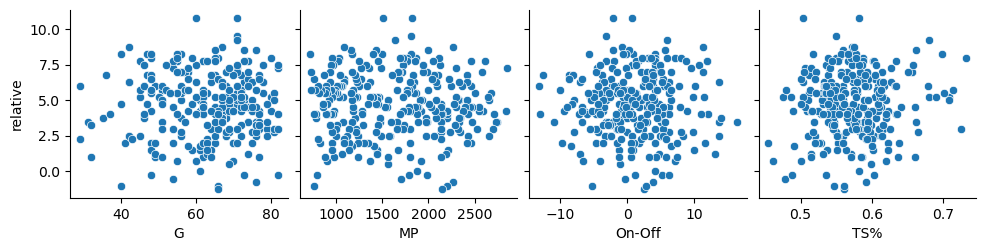

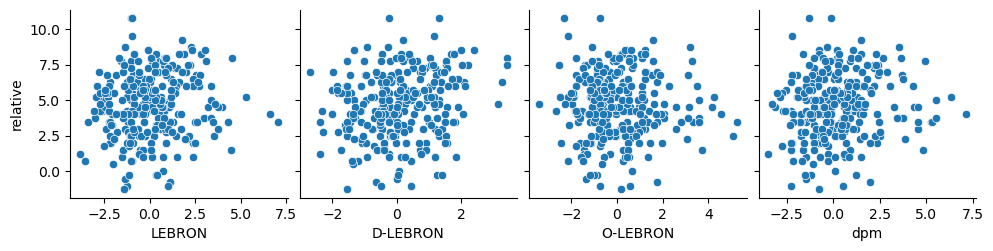

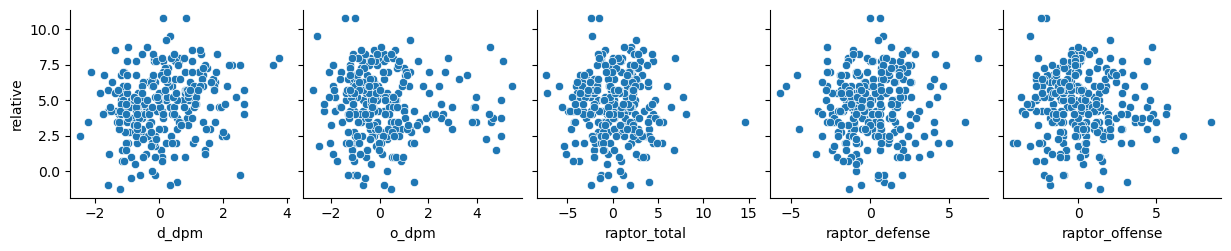

In [10]:
sns.pairplot(
    df2022,
    x_vars=features[0:4],
    y_vars=['relative']
)
plt.show()
sns.pairplot(
    df2022,
    x_vars=features[4:8],
    y_vars=['relative']
)
plt.show()
sns.pairplot(
    df2022,
    x_vars=features[8:13],
    y_vars=['relative']
)
plt.show()

In [11]:
#UNCOMMENT to see ols summary
for model, model_name in zip(single_relative_models, single_relative_model_names):
    print('\n')
    print(f'Model name: {model_name}')
    print(model.summary())
    print('-------------------------------------')



Model name: G_ols
                            OLS Regression Results                            
Dep. Variable:                 Q("G")   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                   0.03130
Date:                Thu, 05 Mar 2026   Prob (F-statistic):              0.860
Time:                        02:53:24   Log-Likelihood:                -1088.9
No. Observations:                 281   AIC:                             2182.
Df Residuals:                     279   BIC:                             2189.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     63.2297      1.618

In [12]:
#UNCOMMENT to see summary table
print(relative_summary.to_string())

                       feature  correlation      coef  r_squared  p_value
G                            G    -0.010591 -0.055242   0.000112  0.85970
MP                          MP    -0.030254 -7.503044   0.000915  0.61356
On-Off                  On-Off     0.010517  0.025007   0.000111  0.86068
TS%                        TS%     0.093416  0.001960   0.008727  0.11820
LEBRON                  LEBRON     0.090692  0.072303   0.008225  0.12936
D-LEBRON              D-LEBRON     0.196131  0.097312   0.038467  0.00095
O-LEBRON              O-LEBRON    -0.038649 -0.025021   0.001494  0.51878
dpm                        dpm     0.094260  0.077853   0.008885  0.11490
d_dpm                    d_dpm     0.217265  0.104641   0.047204  0.00024
o_dpm                    o_dpm    -0.038358 -0.026708   0.001471  0.52193
raptor_total      raptor_total    -0.013265 -0.016754   0.000176  0.82479
raptor_defense  raptor_defense     0.061072  0.050916   0.003730  0.30766
raptor_offense  raptor_offense    -0.0

In [13]:
#sort the table in different ways:

#order by correlation
relative_summary.sort_values('correlation', ascending=False)

#order by coefficient
relative_summary.sort_values('coef', ascending=False)

#order by R squared
relative_summary.sort_values('r_squared', ascending=False)

#order by p_value
relative_summary.sort_values('p_value', ascending=False)

,feature,correlation,coef,r_squared,p_value
On-Off,On-Off,0.010517,0.025007,0.000111,0.86068
G,G,-0.010591,-0.055242,0.000112,0.85970
raptor_total,raptor_total,-0.013265,-0.016754,0.000176,0.82479
MP,MP,-0.030254,-7.503044,0.000915,0.61356
o_dpm,o_dpm,-0.038358,-0.026708,0.001471,0.52193
O-LEBRON,O-LEBRON,-0.038649,-0.025021,0.001494,0.51878
raptor_defense,raptor_defense,0.061072,0.050916,0.003730,0.30766
raptor_offense,raptor_offense,-0.073850,-0.067053,0.005454,0.21716
LEBRON,LEBRON,0.090692,0.072303,0.008225,0.12936
TS%,TS%,0.093416,0.001960,0.008727,0.11820


# 3.analysis using Wingspan
#### 3a. you may skip to 3b for results

In [14]:
df2022_wingspan_corr = df2022[features + ['wingspan_inches']].corr()['wingspan_inches'].drop('wingspan_inches')
single_wingspan_model_names = []
single_wingspan_models = []
for f in features:
    formula = f'Q("{f}") ~ wingspan_inches'
    model = smf.ols(formula, data=df2022).fit()
    single_wingspan_models.append(model)
    single_wingspan_model_names.append(f'{f}_ols')

#table
r_sqr = [] 
p_val = []
coef = []
for model in single_wingspan_models:
    r_sqr.append(model.rsquared)
    p_val.append(model.pvalues['wingspan_inches'])
    coef.append(model.params['wingspan_inches'])
wingspan_summary = pd.DataFrame({
    'feature': features,
    'correlation': df2022_wingspan_corr[features],
    'coef': coef,
    'r_squared': r_sqr,
    'p_value': p_val
    #add more columns as you may want to
})
wingspan_summary['p_value'] = wingspan_summary['p_value'].round(5)

#### 3b. results

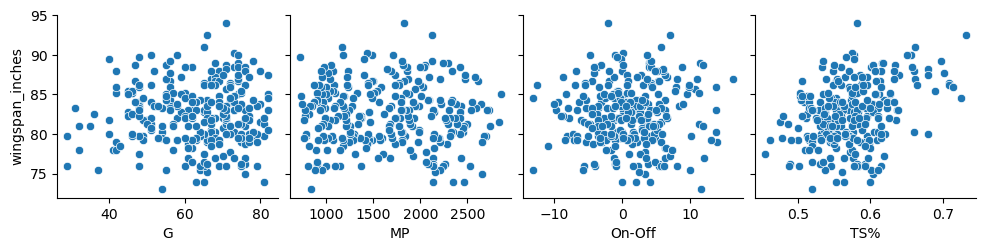

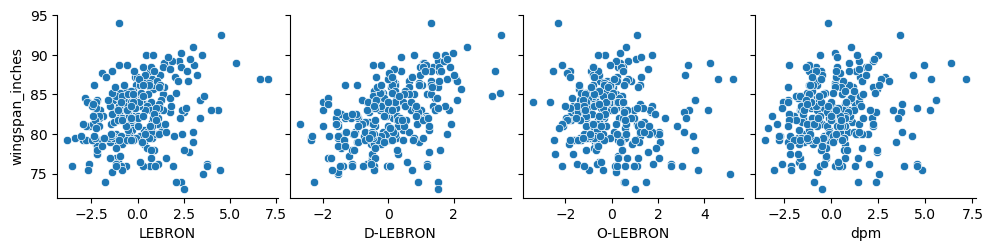

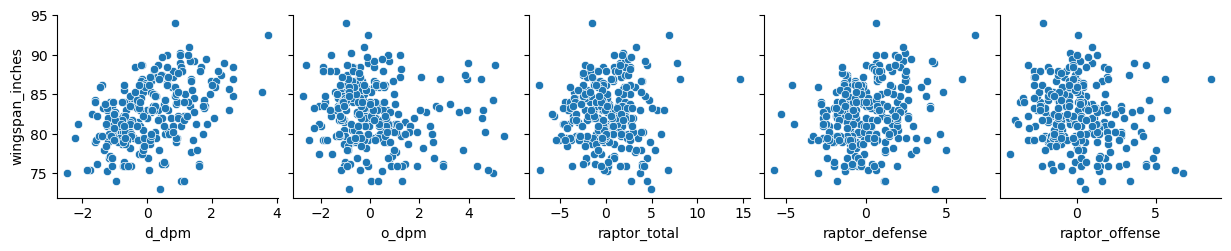

In [15]:
sns.pairplot(
    df2022,
    x_vars=features[0:4],
    y_vars=['wingspan_inches']
)
plt.show()
sns.pairplot(
    df2022,
    x_vars=features[4:8],
    y_vars=['wingspan_inches']
)
plt.show()
sns.pairplot(
    df2022,
    x_vars=features[8:13],
    y_vars=['wingspan_inches']
)
plt.show()

In [16]:
#UNCOMMENT to see the summary
for model, model_name in zip(single_wingspan_models, single_wingspan_model_names):
    print('\n')
    print(f'Model name: {model_name}')
    print(model.summary())
    print('-------------------------------------')



Model name: G_ols
                            OLS Regression Results                            
Dep. Variable:                 Q("G")   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.1047
Date:                Thu, 05 Mar 2026   Prob (F-statistic):              0.746
Time:                        02:53:26   Log-Likelihood:                -1088.9
No. Observations:                 281   AIC:                             2182.
Df Residuals:                     279   BIC:                             2189.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          58.

In [17]:
#UNCOMMENT to see table
# print(wingspan_summary.to_string())

In [18]:
#sort the table in different ways:

#order by correlation
wingspan_summary.sort_values('correlation', ascending=False)

#order by coefficient
wingspan_summary.sort_values('coef', ascending=False)

#order by R squared
wingspan_summary.sort_values('r_squared', ascending=False)

#order by p_value
wingspan_summary.sort_values('p_value', ascending=False)

,feature,correlation,coef,r_squared,p_value
G,G,0.019371,0.058622,0.000375,0.74646
On-Off,On-Off,0.027384,0.037780,0.000750,0.64762
raptor_total,raptor_total,0.049931,0.036589,0.002493,0.40441
MP,MP,-0.050355,-7.245702,0.002536,0.40042
O-LEBRON,O-LEBRON,-0.064427,-0.024200,0.004151,0.28179
o_dpm,o_dpm,-0.114431,-0.046228,0.013094,0.05537
raptor_offense,raptor_offense,-0.156691,-0.082545,0.024552,0.00851
dpm,dpm,0.157206,0.075335,0.024714,0.00829
LEBRON,LEBRON,0.239862,0.110952,0.057534,0.00005
raptor_defense,raptor_defense,0.244908,0.118467,0.059980,0.00003
